In [111]:
from nrem_analysis.constant import RAW_DIR, PROCESSED_DIR, INTERIM_DIR, FIGURES_DIR
from pathlib import Path

import numpy as np
import pynapple as nap
import matplotlib.pyplot as plt
import seaborn as sns

from cmap import Colormap
from matplotlib.colors import TwoSlopeNorm
from scipy import stats

MOUSE_IDS = ["99b", "103c", "106b", "107b", "110b"]

cm = Colormap("colorbrewer:Set2")
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
dashed_style = (0, (5, 5))

plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       320,
    "font.family":       "sans-serif",
    'font.sans-serif':   "Arial",
    "axes.grid":         False,
    "figure.constrained_layout.use": True,
})

def plot_heatmaps(mats, times, titles, norm=None, cmap="hot", figsize=None):
    """Plot [T, N] matrices as side-by-side heatmaps."""
    n = len(mats)

    if figsize is None:
        figsize = (4 * n, 4)

    fig, axes = plt.subplots(
        1, n, figsize=figsize, sharey=True, squeeze=False
    )
    axes = axes.ravel()

    for ax, mat, time, title in zip(axes, mats, times, titles):
        im = ax.imshow(
            mat.T,
            aspect="auto",
            origin="lower",
            extent=[time[0], time[-1], 0, mat.shape[1]],
            cmap=cmap,
            norm=norm,
        )

        ax.set_title(title)
        fig.colorbar(im, ax=ax)

    return fig, axes

def time_index(t, target):
    return np.argmin(np.abs(t - target))

def amplitude_at_threshold(sta, t, threshold):
    before_idx = time_index(t, -threshold)
    after_idx = time_index(t, threshold)
    return sta[after_idx, :] - sta[before_idx, :]

def plot_scatter_with_regression(ax, x, y, title=None, xlabel=None, ylabel=None, line_color='tab:red', scatter_color='k'):
    fit = stats.linregress(x, y)
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = fit.intercept + fit.slope * x_fit

    ax.scatter(x, y, s=15, c=scatter_color, alpha=0.8)
    ax.plot(x_fit, y_fit, color=line_color, linewidth=0.7, linestyle='--')
    ax.axhline(0, color='0.5', linestyle='--', linewidth=1)
    ax.axvline(0, color='0.5', linestyle='--', linewidth=1)

    label = (
        f'R = {fit.rvalue:.2f}\n'
        f'p = {fit.pvalue:.2g}\n'
    )

    ax.text(0.05, 0.95, label, transform=ax.transAxes, ha='left', va='top', fontsize=14)
    if title is not None:
        ax.set_title(title, fontsize=18)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=18)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=18)

In [ ]:
tsi = []
sta_nrem = []
sta_random = []
midx = []
random_midx = []

for mouse_idx, mouse_id in enumerate(MOUSE_IDS):
    turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")  
    sta = nap.load_file(INTERIM_DIR / "sta" / mouse_id / "sta_nrem_upstate.npz")
    mouse_sta_random = nap.load_file(INTERIM_DIR / "sta" / mouse_id / "sta_random_spikes.npz")

    if sta.shape[0] == 103:
        sta = sta[1:-1]
    if mouse_sta_random.shape[0] == 103:
        mouse_sta_random = mouse_sta_random[1:-1]
    
    times = sta.t

    sta_nrem.append(sta.d)
    sta_random.append(mouse_sta_random.d)
    
    midx.append(np.zeros_like(turn_units['turn_index']) + mouse_idx)
    random_midx.append(np.full(mouse_sta_random.shape[1], mouse_idx, dtype=int))
    tsi.append(turn_units['turn_index'])
    
tsi = np.concatenate(tsi)
midx = np.concatenate(midx)
random_midx = np.concatenate(random_midx)

order = np.argsort(tsi)
tsi = tsi[order]
midx = midx[order]

In [113]:
sta_nrem = np.rad2deg(np.column_stack(sta_nrem))[:, order]
sta_random = np.rad2deg(np.column_stack(sta_random))
sta_original = nap.load_file(PROCESSED_DIR / "dual" / "sta_awake_sorted.npz")

nanmask = np.any(np.isnan(sta_nrem), axis=0)
tsi = tsi[~nanmask]
zero_cross = np.argmin(np.abs(tsi)).item()

midx = midx[~nanmask]
sta_original = sta_original[:, ~nanmask]
sta_nrem = sta_nrem[:, ~nanmask]

In [114]:
sta_nrem = nap.TsdFrame(t=np.round(times, decimals=3), d=sta_nrem)
sta_random = nap.TsdFrame(t=np.round(times, decimals=3), d=sta_random)

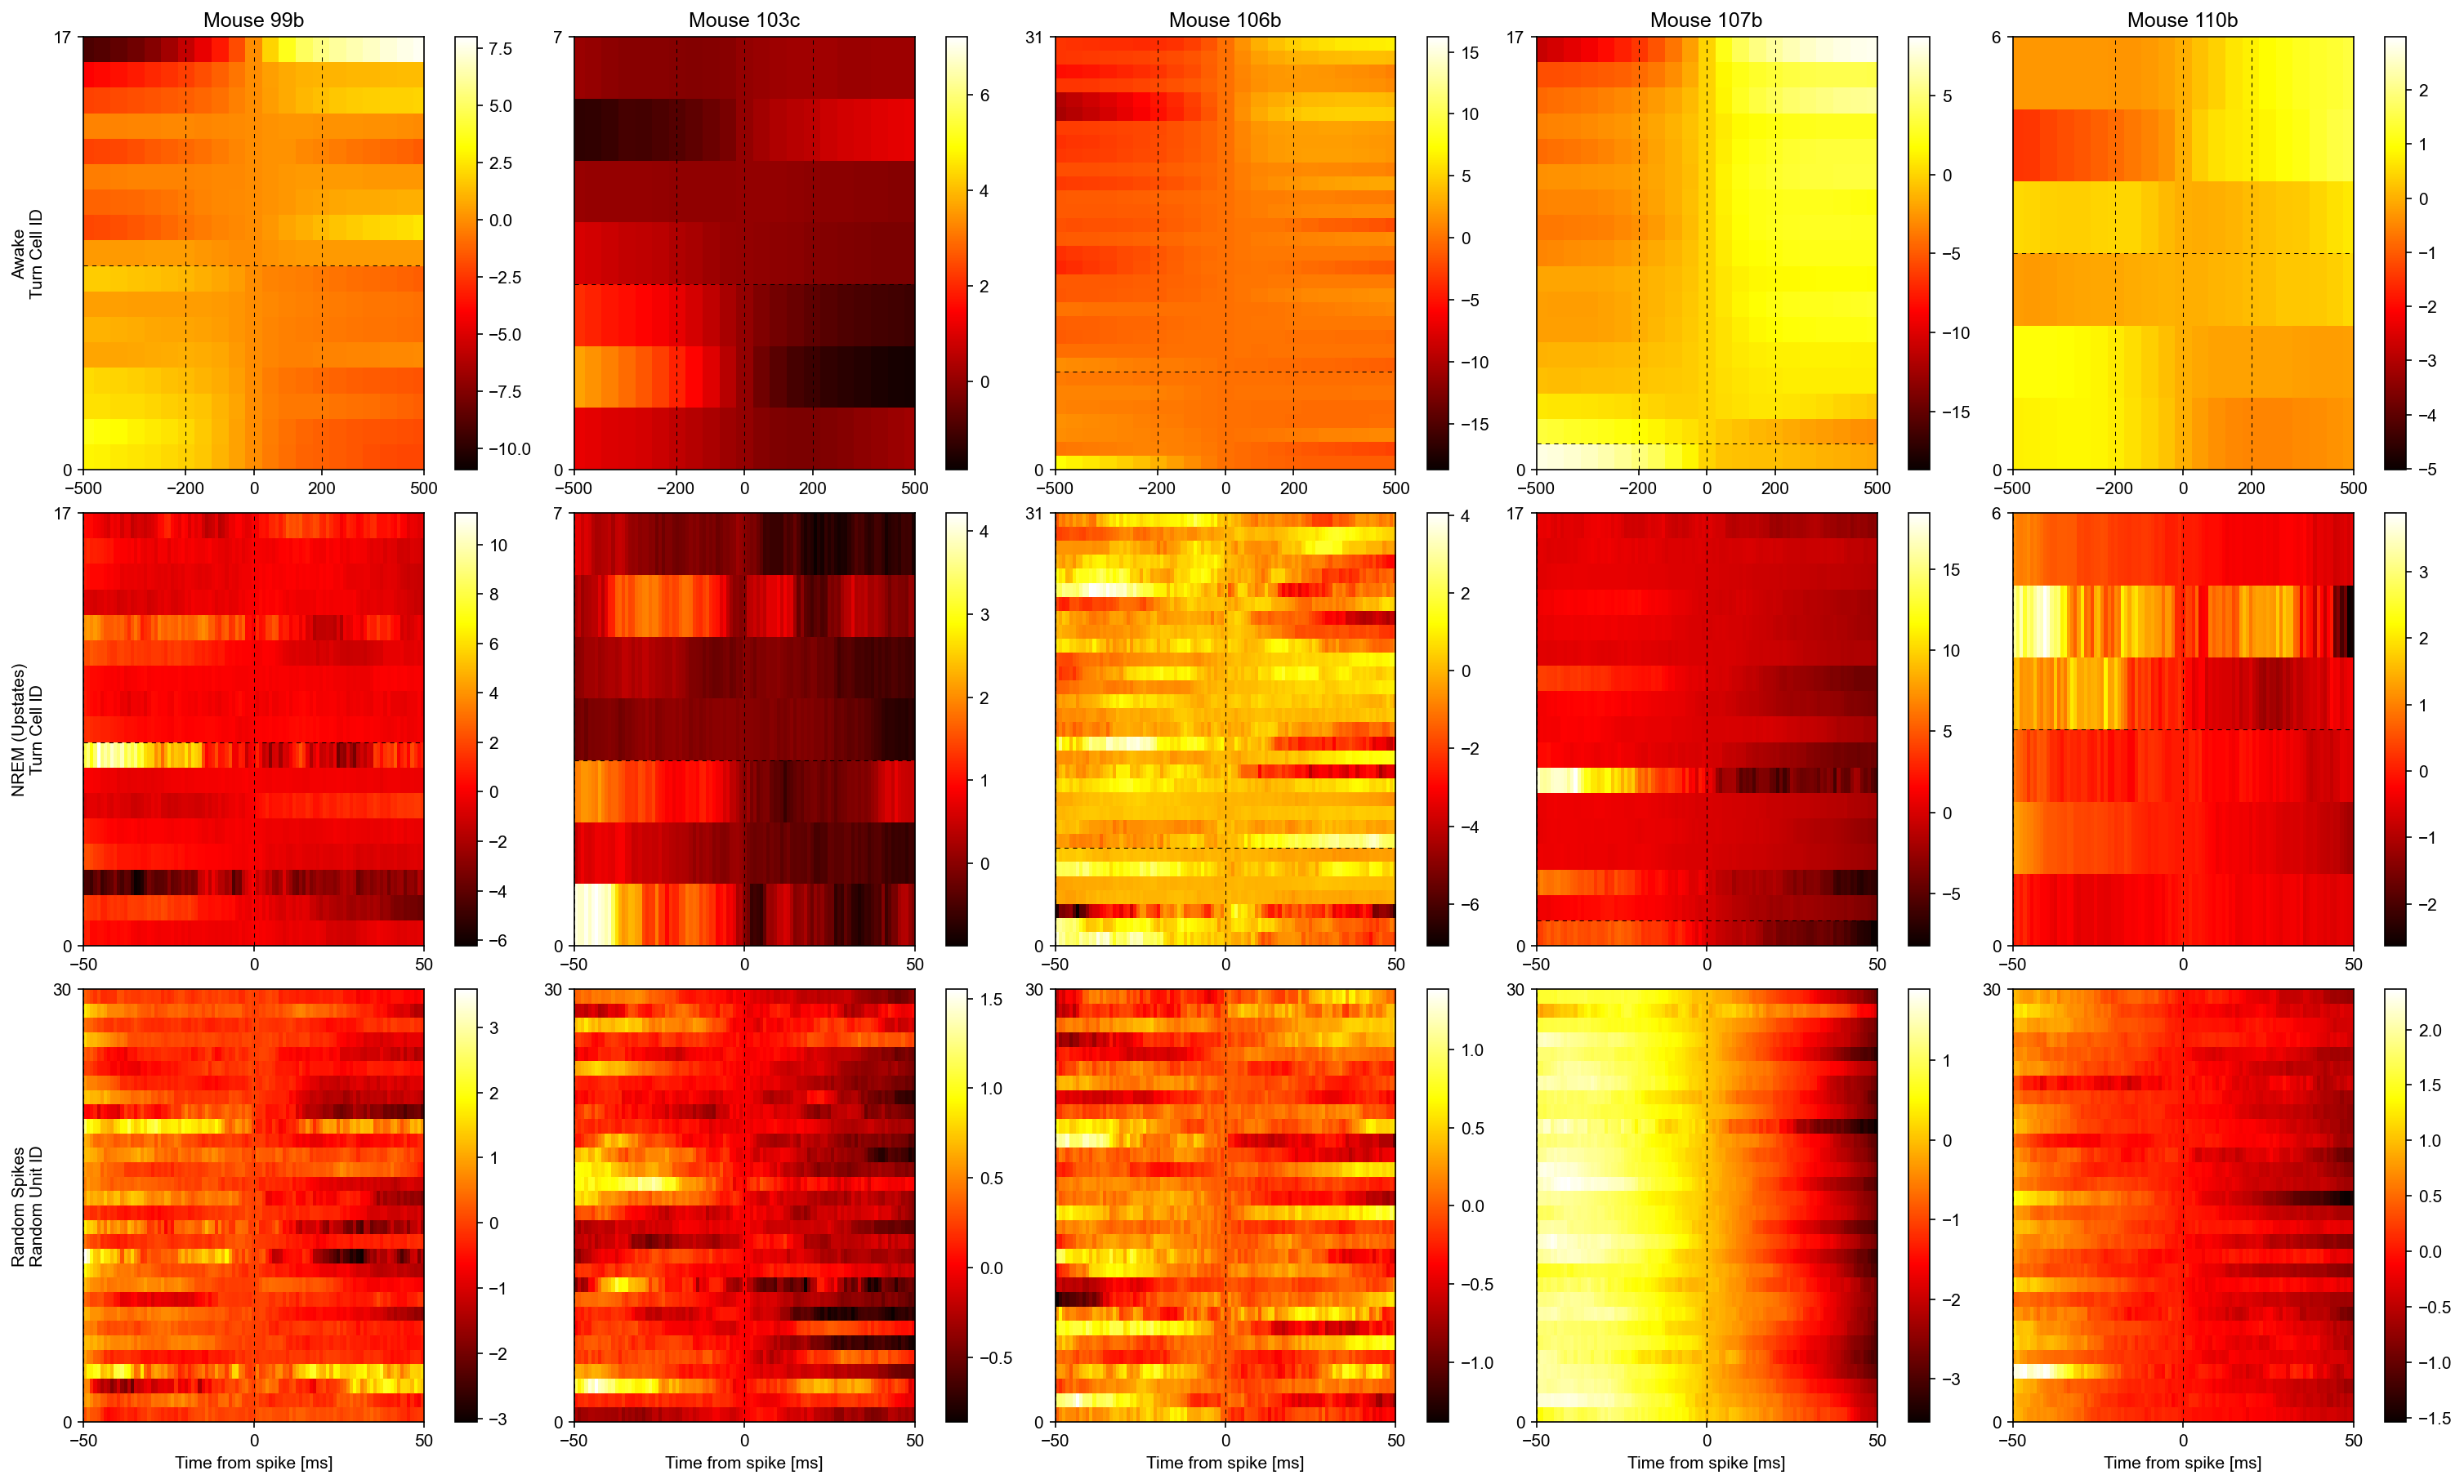

In [115]:
fig, axes = plt.subplots(
    3, len(MOUSE_IDS), figsize=(4 * len(MOUSE_IDS), 12), sharey=False, squeeze=False
)
heatmap_norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
row_specs = [
    ("Awake", sta_original, (-500, 500), [-500, -200, 0, 200, 500], 200, midx, True, "Turn Cell ID"),
    ("NREM (Upstates)", sta_nrem, (-50, 50), [-50, 0, 50], 50, midx, True, "Turn Cell ID"),
    ("Random Spikes", sta_random, (-50, 50), [-50, 0, 50], 50, random_midx, False, "Random Unit ID"),
]

for mouse_idx, mouse_id in enumerate(MOUSE_IDS):
    turn_mouse_mask = midx == mouse_idx
    mouse_zero_cross = np.argmin(np.abs(tsi[turn_mouse_mask])).item()

    for row_idx, (state, sta, xlim, xticks, threshold, mouse_indices, show_tsi_divider, unit_label) in enumerate(row_specs):
        ax = axes[row_idx, mouse_idx]
        mouse_mask = mouse_indices == mouse_idx
        mouse_sta = sta.d[:, mouse_mask]

        im = ax.imshow(
            mouse_sta.T,
            aspect="auto",
            origin="lower",
            extent=[sta.times('ms')[0], sta.times('ms')[-1], 0, mouse_sta.shape[1]],
            cmap="hot",
            # norm=heatmap_norm,
        )

        if row_idx == 2:
            ax.set_xlabel("Time from spike [ms]")
        ax.set_xlim(xlim)
        ax.set_xticks(xticks)
        ax.set_yticks([0, mouse_sta.shape[1]])
        ax.axvline(0, color="k", linestyle=dashed_style, linewidth=0.5)
        ax.axvline(threshold, color="k", linestyle=dashed_style, linewidth=0.5)
        ax.axvline(-threshold, color="k", linestyle=dashed_style, linewidth=0.5)
        if show_tsi_divider:
            ax.axhline(mouse_zero_cross, color="k", linestyle=dashed_style, linewidth=0.5)
        
        fig.colorbar(im, ax=ax)

        if mouse_idx == 0:
            ax.set_ylabel(f"{state}\n{unit_label}")

    axes[0, mouse_idx].set_title(f"Mouse {mouse_id}")

plt.savefig(FIGURES_DIR / "sta_per_mouse.svg", format='svg', bbox_inches='tight')
plt.savefig(FIGURES_DIR / "sta_per_mouse.png", format='png', bbox_inches='tight')

plt.show()

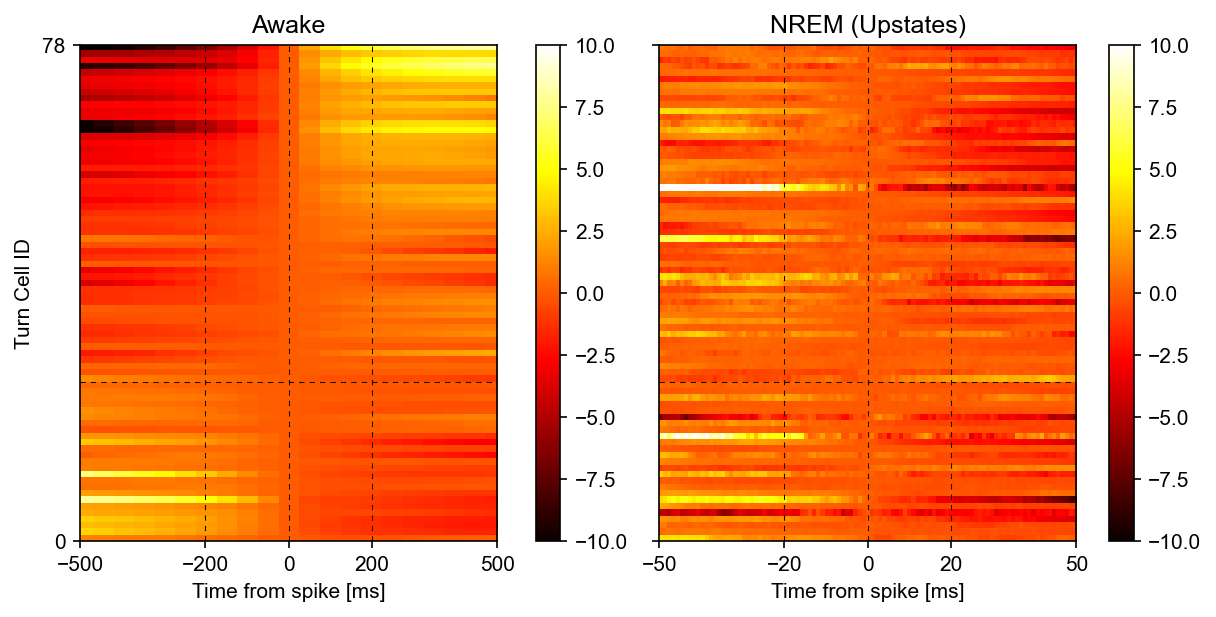

In [116]:
fig, axes = plot_heatmaps(
    mats=[sta_original.d, sta_nrem.d],
    times=[sta_original.times('ms'), sta_nrem.times('ms')],
    titles=["Awake", "NREM (Upstates)"],
    norm=TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10),
)

for ax in axes:
    ax.axvline(0, color="k", linestyle=dashed_style, linewidth=0.5)
    ax.axhline(zero_cross, color="k", linestyle=dashed_style, linewidth=0.5)
    ax.set_xlabel("Time from spike [ms]")

axes[0].set_ylabel("Turn Cell ID")
axes[0].set_xlim([-500, 500])
axes[0].set_xticks([-500, -200, 0, 200, 500])
axes[0].set_yticks([0, len(sta_original.columns)])
axes[0].axvline(200, color="k", linestyle=dashed_style, linewidth=0.5)
axes[0].axvline(-200, color="k", linestyle=dashed_style, linewidth=0.5)

axes[1].set_xlim((-50, 50))
axes[1].set_xticks([-50, -20, 0, 20, 50])
axes[1].axvline(20, color="k", linestyle=dashed_style, linewidth=0.5)
axes[1].axvline(-20, color="k", linestyle=dashed_style, linewidth=0.5)

plt.savefig(FIGURES_DIR / "sta_norm.svg", format='svg', bbox_inches='tight')
plt.savefig(FIGURES_DIR / "sta_norm.png", format='png', bbox_inches='tight')

plt.show()

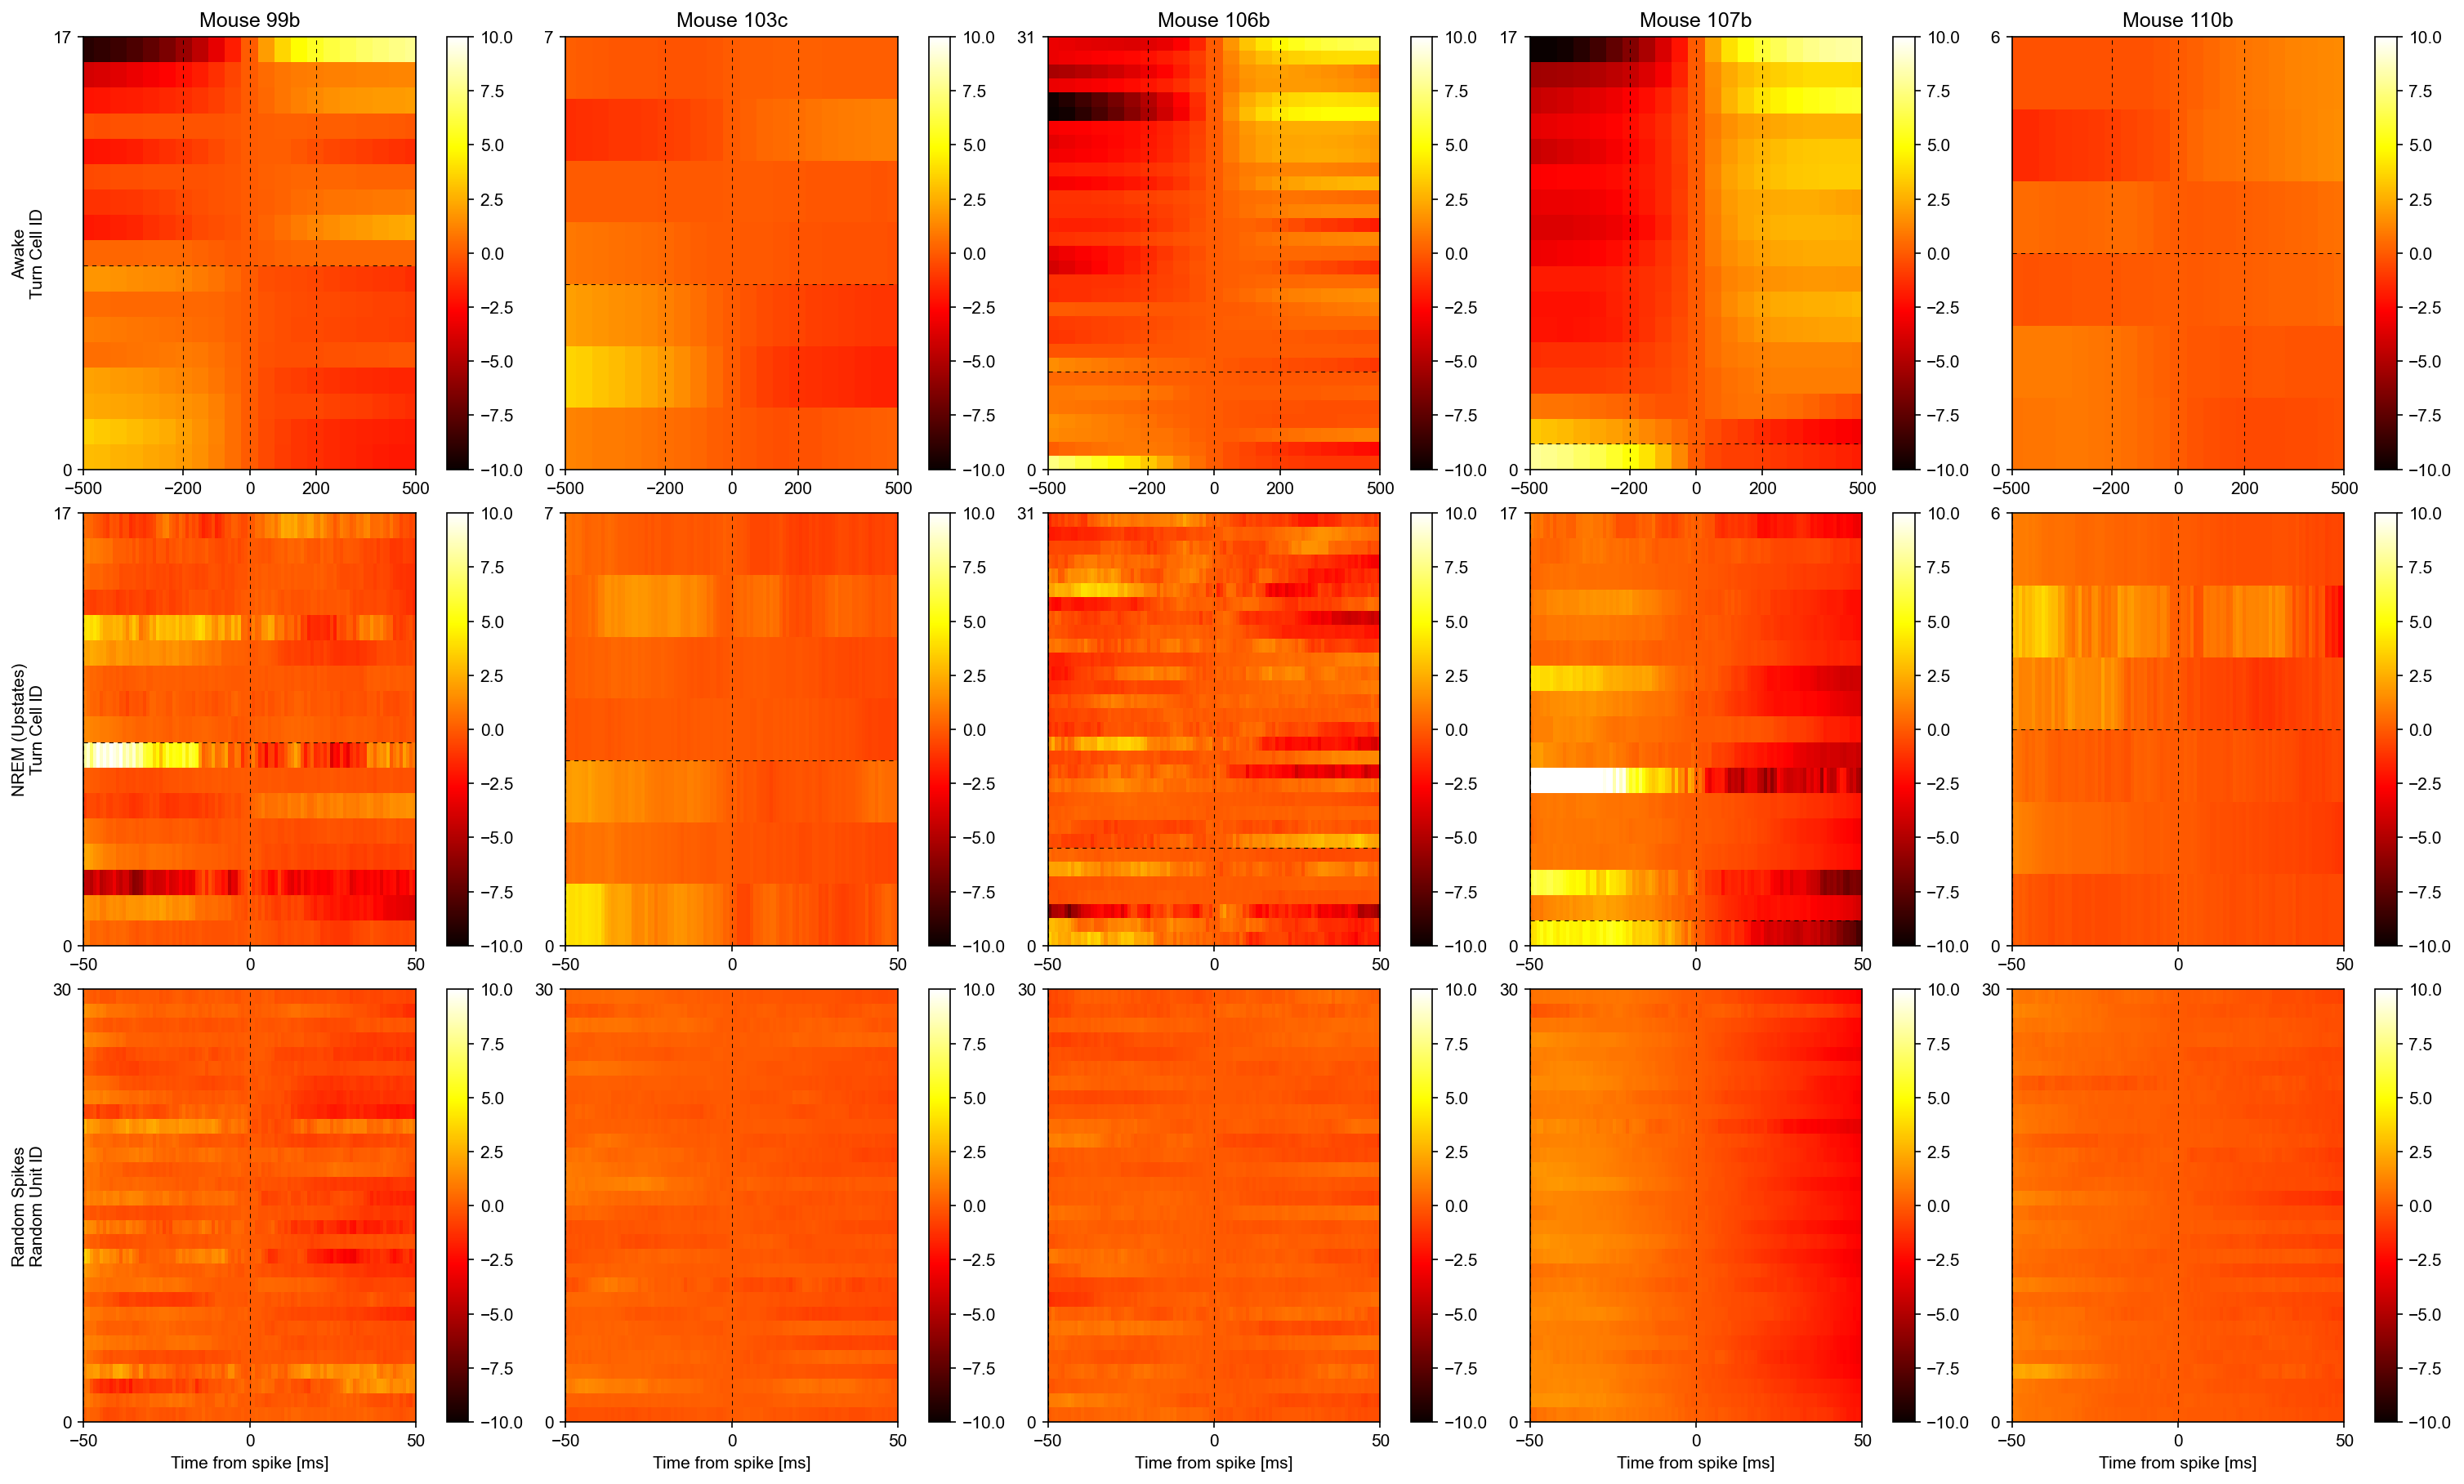

In [117]:
fig, axes = plt.subplots(
    3, len(MOUSE_IDS), figsize=(4 * len(MOUSE_IDS), 12), sharey=False, squeeze=False
)
heatmap_norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
row_specs = [
    ("Awake", sta_original, (-500, 500), [-500, -200, 0, 200, 500], 200, midx, True, "Turn Cell ID"),
    ("NREM (Upstates)", sta_nrem, (-50, 50), [-50, 0, 50], 50, midx, True, "Turn Cell ID"),
    ("Random Spikes", sta_random, (-50, 50), [-50, 0, 50], 50, random_midx, False, "Random Unit ID"),
]

for mouse_idx, mouse_id in enumerate(MOUSE_IDS):
    turn_mouse_mask = midx == mouse_idx
    mouse_zero_cross = np.argmin(np.abs(tsi[turn_mouse_mask])).item()

    for row_idx, (state, sta, xlim, xticks, threshold, mouse_indices, show_tsi_divider, unit_label) in enumerate(row_specs):
        ax = axes[row_idx, mouse_idx]
        mouse_mask = mouse_indices == mouse_idx
        mouse_sta = sta.d[:, mouse_mask]

        im = ax.imshow(
            mouse_sta.T,
            aspect="auto",
            origin="lower",
            extent=[sta.times('ms')[0], sta.times('ms')[-1], 0, mouse_sta.shape[1]],
            cmap="hot",
            norm=heatmap_norm,
        )

        if row_idx == 2:
            ax.set_xlabel("Time from spike [ms]")
        ax.set_xlim(xlim)
        ax.set_xticks(xticks)
        ax.set_yticks([0, mouse_sta.shape[1]])
        ax.axvline(0, color="k", linestyle=dashed_style, linewidth=0.5)
        ax.axvline(threshold, color="k", linestyle=dashed_style, linewidth=0.5)
        ax.axvline(-threshold, color="k", linestyle=dashed_style, linewidth=0.5)
        if show_tsi_divider:
            ax.axhline(mouse_zero_cross, color="k", linestyle=dashed_style, linewidth=0.5)
        
        fig.colorbar(im, ax=ax)

        if mouse_idx == 0:
            ax.set_ylabel(f"{state}\n{unit_label}")

    axes[0, mouse_idx].set_title(f"Mouse {mouse_id}")

plt.savefig(FIGURES_DIR / "sta_per_mouse.svg", format='svg', bbox_inches='tight')
plt.savefig(FIGURES_DIR / "sta_per_mouse.png", format='png', bbox_inches='tight')

plt.show()

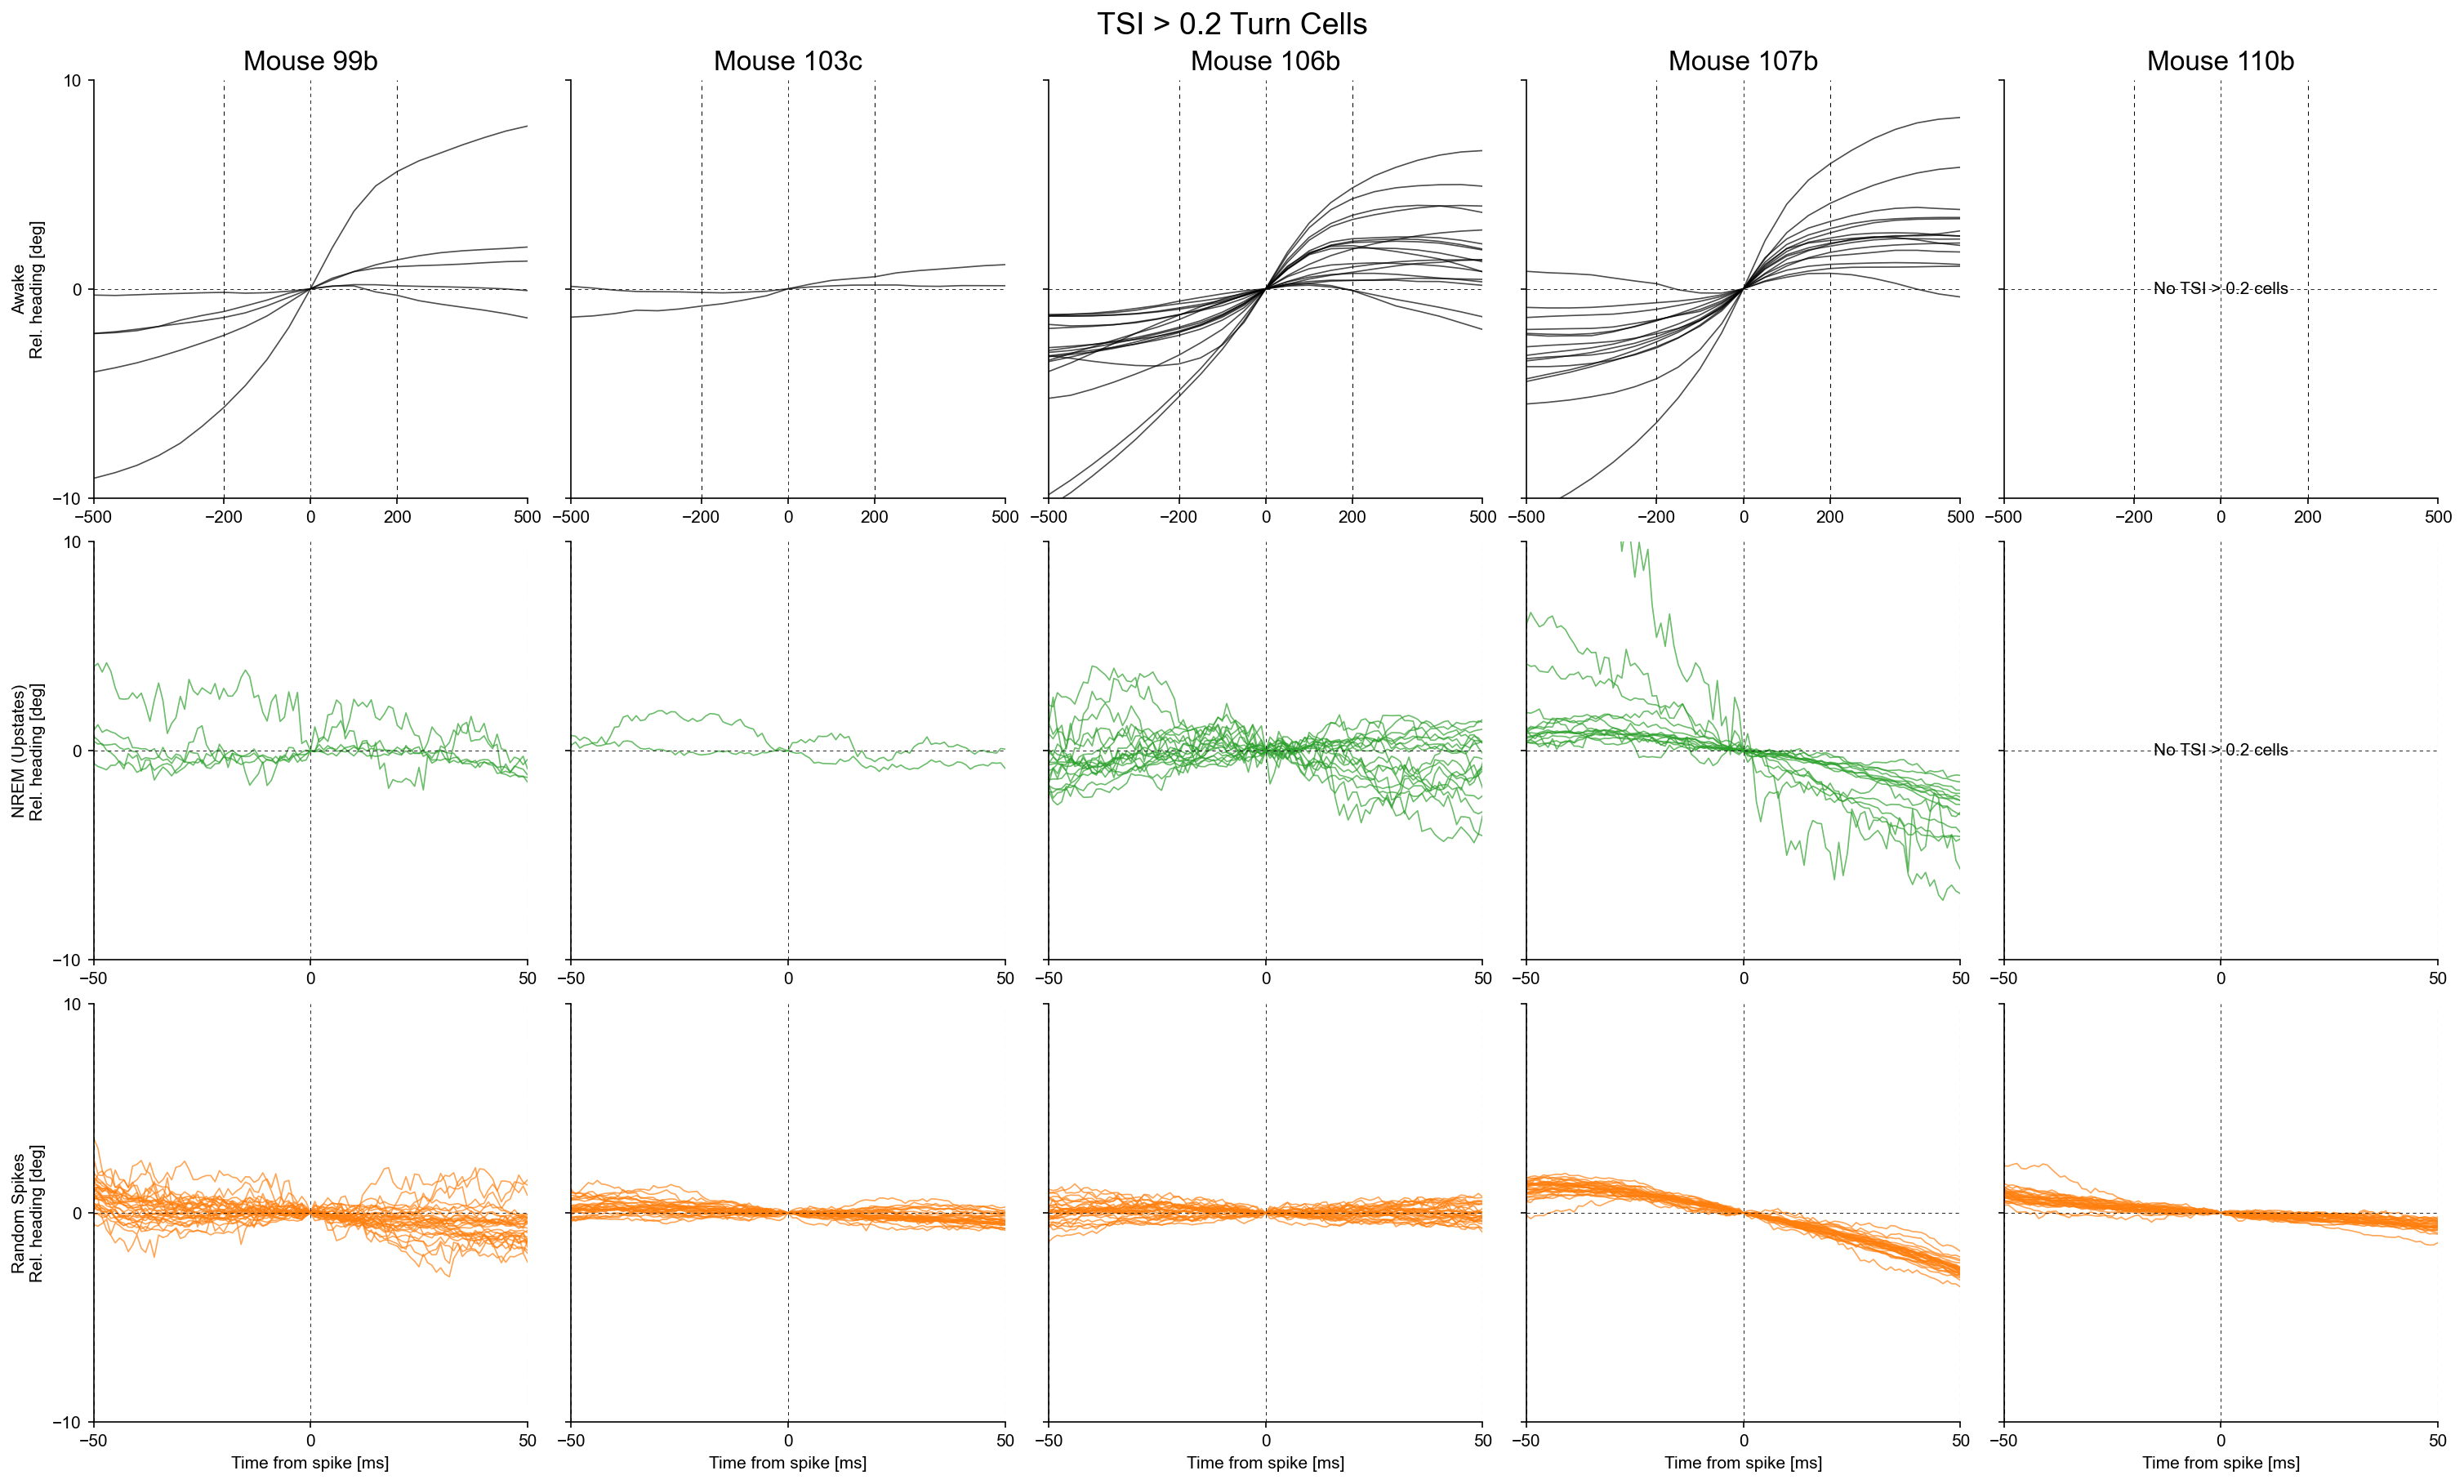

In [118]:
fig, axes = plt.subplots(
    3, len(MOUSE_IDS), figsize=(4 * len(MOUSE_IDS), 12), sharey=True, squeeze=False
)
row_specs = [
    ("Awake", sta_original, (-500, 500), [-500, -200, 0, 200, 500], 200, "k", midx, True),
    ("NREM (Upstates)", sta_nrem, (-50, 50), [-50, 0, 50], 50, "tab:green", midx, True),
    ("Random Spikes", sta_random, (-50, 50), [-50, 0, 50], 50, "tab:orange", random_midx, False),
]

for mouse_idx, mouse_id in enumerate(MOUSE_IDS):
    for row_idx, (state, sta, xlim, xticks, threshold, color, mouse_indices, apply_tsi_filter) in enumerate(row_specs):
        ax = axes[row_idx, mouse_idx]
        mouse_mask = mouse_indices == mouse_idx

        if apply_tsi_filter:
            mouse_mask &= tsi > 0.2
        ax.plot(
            sta.times('ms'), sta.d[:, mouse_mask], color=color, alpha=0.7, linewidth=0.8
        )

        if not np.any(mouse_mask):
            ax.text(
                0.5, 0.5, "No TSI > 0.2 cells" if apply_tsi_filter else "No random units",
                transform=ax.transAxes, ha="center", va="center",
            )

        ax.set_xlim(xlim)
        ax.set_ylim((-10, 10))
        ax.set_xticks(xticks)
        ax.set_yticks([-10, 0, 10])
        ax.axhline(0, color="k", linestyle=dashed_style, linewidth=0.4)
        ax.axvline(0, color="k", linestyle=dashed_style, linewidth=0.4)
        ax.axvline(threshold, color="k", linestyle=dashed_style, linewidth=0.5)
        ax.axvline(-threshold, color="k", linestyle=dashed_style, linewidth=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if row_idx == 2:
            ax.set_xlabel("Time from spike [ms]")

        if mouse_idx == 0:
            ax.set_ylabel(f"{state}\nRel. heading [deg]")

    axes[0, mouse_idx].set_title(f"Mouse {mouse_id}", fontsize=16)

fig.suptitle("TSI > 0.2 Turn Cells", fontsize=18)
plt.savefig(FIGURES_DIR / "sta_cw_turns_per_mouse.png", format='png', bbox_inches='tight')
plt.savefig(FIGURES_DIR / "sta_cw_turns_per_mouse.svg", format='svg', bbox_inches='tight')
plt.show()